In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import cv2
from keras.layers import Flatten, Dense, GlobalAveragePooling2D, BatchNormalization, Dropout
from tensorflow.keras.regularizers import l2
from keras.applications.vgg16 import VGG16
from keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

In [2]:
mask_data_train = 'Face Mask Dataset/Train'
mask_data_test = 'Face Mask Dataset/Test'
val_data_train = 'Face Mask Dataset/Validation'

In [3]:
img_width = 150
img_height = 150

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(mask_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 20815 files belonging to 2 classes.


In [5]:
data_test = tf.keras.utils.image_dataset_from_directory(mask_data_test,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 992 files belonging to 2 classes.


In [6]:
val_train = tf.keras.utils.image_dataset_from_directory(val_data_train,
                                                        shuffle=True, 
                                                        image_size=(img_width, img_height),
                                                        batch_size=32, 
                                                        validation_split=False)

Found 800 files belonging to 2 classes.


In [7]:
data_cat = data_train.class_names
data_cat

['WithMask', 'WithoutMask']

In [8]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

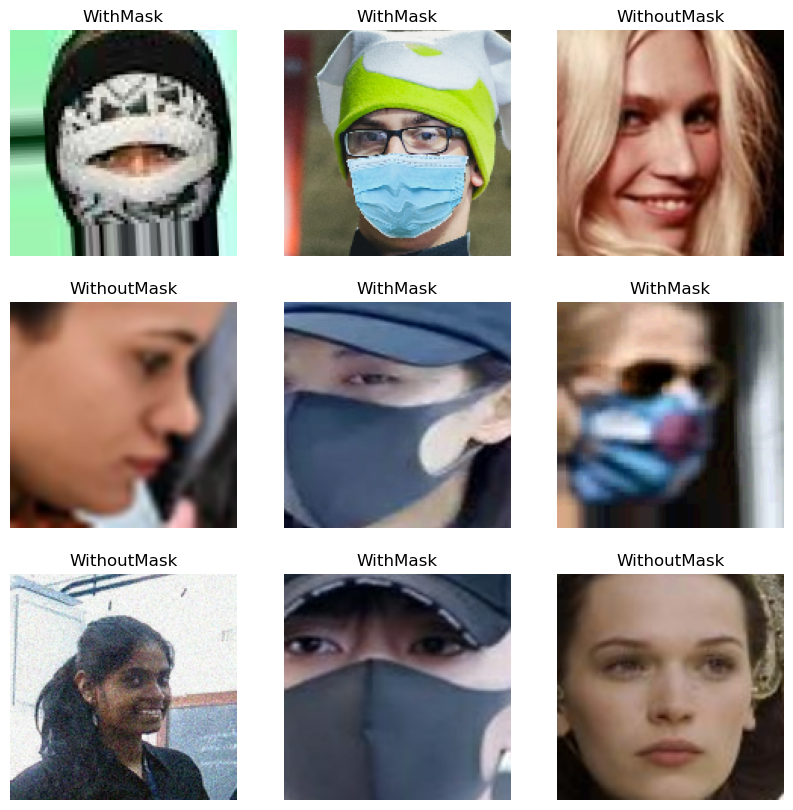

In [9]:
plt.figure(figsize=(10, 10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3, i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [10]:
CN_bas = MobileNetV3Large(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

D:\anaconda\Lib\site-packages\keras\src\applications\mobilenet_v3.py:519: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


In [11]:
CN_bas.summary()

Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 150, 150,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 75, 75,    │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 75, 75,    │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 75, 75,    │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 75, 75,    │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 75, 75,    │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 75, 75,    │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 75, 75,    │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 77, 77,    │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 38, 38,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 38, 38,    │        256 │ expanded_conv_1_

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 2,971,952 (11.34 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [12]:
CN_bas.trainable = False

In [13]:
model = Sequential()
model.add(CN_bas)
model.add(GlobalAveragePooling2D())
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(1, activation='sigmoid'))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 5, 5, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 960)            │         3,840 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,246,465 (12.38 MB)

 Trainable params: 248,193 (969.50 KB)

 Non-trainable params: 2,998,272 (11.44 MB)

In [15]:
def process(image, label):
    image =preprocess_input(image)
    return image, label
data_train = data_train.map(process)
val_train = val_train.map(process)

In [16]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001), 
            loss = keras.losses.BinaryCrossentropy(), metrics = ['accuracy'])

In [17]:
epochs = 10
history = model.fit(data_train,validation_data=val_train, epochs = epochs)

Epoch 1/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 183s 272ms/step - accuracy: 0.9594 - loss: 0.4890 - val_accuracy: 0.9950 - val_loss: 0.3641
Epoch 2/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 178s 273ms/step - accuracy: 0.9846 - loss: 0.3670 - val_accuracy: 0.9987 - val_loss: 0.3032
Epoch 3/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 178s 273ms/step - accuracy: 0.9884 - loss: 0.3055 - val_accuracy: 1.0000 - val_loss: 0.2528
Epoch 4/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 180s 277ms/step - accuracy: 0.9904 - loss: 0.2549 - val_accuracy: 1.0000 - val_loss: 0.2112
Epoch 5/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 179s 275ms/step - accuracy: 0.9927 - loss: 0.2103 - val_accuracy: 1.0000 - val_loss: 0.1755
Epoch 6/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 177s 272ms/step - accuracy: 0.9944 - loss: 0.1751 - val_accuracy: 1.0000 - val_loss: 0.1446
Epoch 7/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 181s 278ms/step - accuracy: 0.9939 - loss: 0.1469 - val_accuracy: 1.0000 - val_loss: 0.1202
Epoch 8/10
651/651 ━━━━━━━━━━━━━━━━━━━━ 181s 278ms/step - accuracy: 0.9949 -

In [18]:
epoch_range = range(epochs)
plt.figure(figsize=(8,8))

<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

In [19]:
image = '1.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_width, img_height))
img_arr = tf.keras.utils.img_to_array(image)
img_bat = tf.expand_dims(img_arr, 0)

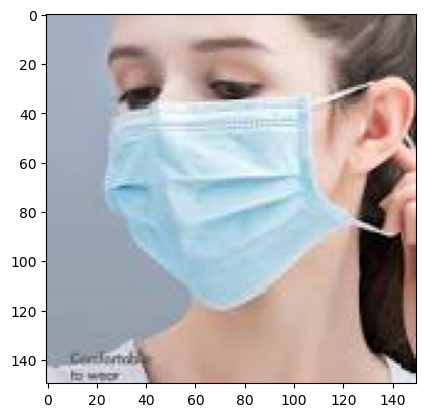

In [20]:
plt.imshow(image)

In [21]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [22]:
predict

array([[0.00017217]], dtype=float32)

In [23]:
cap = cv2.VideoCapture(0)

In [24]:
def detect_face_mask(face):
    face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
    face = cv2.resize(face, (150,150))
    face = preprocess_input(face.astype(np.float32))
    face = np.expand_dims(face, axis=0)
    prediction = model.predict(face, verbose=0)[0][0]
    return prediction

In [25]:
def draw_label(img, text, pos, bg_color):
    text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, cv2.FILLED)
    end_x = pos[0] + text_size[0][0] + 2
    end_y = pos[1] + text_size[0][1] - 2

    cv2.rectangle(img, pos, (end_x, end_y), bg_color, cv2.FILLED)
    cv2.putText(img, text, pos, cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 1, cv2.LINE_AA)

In [26]:
haar = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

In [27]:
def detect_face(img):
    cood = haar.detectMultiScale(img)
    return cood

In [28]:
while True:
    ret, frame = cap.read()
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = haar.detectMultiScale(gray, 1.1, 4)
    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        pred = detect_face_mask(face)
        if pred >= 0.5:
            label = "No Mask"
            color = (0,0,255)
        else:
            label = "Mask"
            color = (0,255,0)
        cv2.rectangle(frame, (x,y), (x+w,y+h), color, 2)
        draw_label(frame, label, (x,y-10), color)
    cv2.imshow("Video", frame)
    if cv2.waitKey(1) & 0xFF == ord('x'):
        break
cap.release()
cv2.destroyAllWindows()